In [63]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt


runfiles = ['no_barrier_runfile','time_analysis_new_source_ten_minute']#_ten_minutes'] ##OLD, NEW

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



MAX_Q15 = 32767 / 32768


In [64]:
import numpy as np

# Your known calibration points
cal_adu = np.array([450, 1243, 12216])
cal_kev = np.array([6.395, 14.4129, 122.06])

# Calculate the quadratic fit (2nd-degree polynomial)
a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

print(f"a = {a:e}")
print(f"b = {b:e}")
print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu




a = -2.555374e-08
b = 1.015411e-02
c = 1.830826e+00


In [65]:


def load_and_process_run(runfile):
    """Loads binary event data, fits clock drift, and returns unpacked arrays."""
    raw = load_run(f"{runfile}/events_*.bin")
    ts_us, energy, chb = unpack(raw)

    # Filter out invalid non-positive timestamps
    valid_mask = ts_us > 0
    # print(np.any(mask[50:]))
    ts_us = ts_us[valid_mask]
    energy = energy[valid_mask]
    chb = chb[valid_mask]

    if len(ts_us) > 1:
        span_s = (ts_us[-1] - ts_us[0]) / 1e6
        print(f"[{runfile}] {len(ts_us)} events, span {span_s:.1f} s")
    else:
        print(f"[{runfile}] No events found.")

    a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
    print(f"[{runfile}] Crystal drift: {ppm:+.1f} ppm")

    t_unix = counter_to_unix(ts_us, a, b)

    return {
        "ts_us": ts_us,
        "energy": energy,
        "chb": chb,
        "t_unix": t_unix,
    }




In [66]:

# --- 2. Configurations & Data Loading ---
RUN_CONFIGS = [
    {"runfile": runfiles[0], "label": "No Absorber"},
    {"runfile": runfiles[1], "label": "With Absorber"},
]


# Sequential loading and mapping
processed_runs = []
for config in RUN_CONFIGS:
    data = load_and_process_run(config["runfile"])
    data["label"] = config["label"]
    processed_runs.append(data)


# --- 3. Dynamic Plotting Pipeline ---
fig, axes = plt.subplots(
    1, len(processed_runs), figsize=(8 * len(processed_runs), 5.5)
)
if len(processed_runs) == 1:
    axes = [axes]

for run, ax in zip(processed_runs, axes):
    ts_us = run["ts_us"]
    label_prefix = run["label"]

    # Compute inter-arrival times (dt) in milliseconds
    dt_ms = np.diff(ts_us.astype(np.float64)) / 1e3

    # Histogram calculation
    bins = 100
    counts, bin_edges = np.histogram(dt_ms, bins=bins)
    # Limit the histogram range to sub-20 ms range
    # counts, bin_edges = np.histogram(dt_ms, bins=100, range=(0, 15))

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]  # Bin width in ms

    # Fit region above dead time cutoff (4.8 us = 0.0048 ms)
    dead_time_ms = 4.8 / 1e3
    mask = bin_centers > dead_time_ms

    fit_x = bin_centers[mask]
    fit_y = counts[mask]
    N_valid = np.sum(fit_y)
    print_mask = (bin_centers > 150) 
    # print(bin_centers[print_mask])
    print(np.sum(counts[print_mask]))
    # Normalized 1-parameter exponential model
    def exp_func(
        dt,
        lmbda,
        N_valid=N_valid,
        bin_width=bin_width,
        dead_time_ms=dead_time_ms,
    ):
        return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_ms))

    # Perform fit
    popt, _ = curve_fit(exp_func, fit_x, fit_y, p0=[1.0])
    fit_lambda = popt[0]

    # Plotting
    nonzero_mask = counts > 0
    zero_mask = counts == 0

    # Non-zero counts
    ax.scatter(
        bin_centers[nonzero_mask],
        counts[nonzero_mask],
        color="navy",
        alpha=0.8,
        s=35,
        label="Measured Data (Counts > 0)",
    )

    # Zero counts
    baseline_zero_y = 0.3
    ax.scatter(
        bin_centers[zero_mask],
        np.full(np.sum(zero_mask), baseline_zero_y),
        color="crimson",
        marker="x",
        s=45,
        linewidth=1.5,
        label="Zero-Count Bins (Counts = 0)",
    )

    # Exponential fit curve
    ax.plot(
        fit_x,
        exp_func(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\mathrm{{ms}}^{{-1}}$)",
    )

    # Dead time threshold vertical line
    ax.axvline(
        dead_time_ms,
        color="black",
        linestyle=":",
        alpha=0.7,
        label=f"Dead Time Limit ({dead_time_ms:.4f} ms)",
    )

    ax.set_yscale("log")
    ax.set_ylim(bottom=0.2)
    ax.set_xlabel(r"Interval (ms)")
    # ax.set_xlim(0,÷00)
    ax.set_ylabel("Counts")
    ax.set_title(
        f"{label_prefix}: Analysis of Event Counts in {bin_width * 1e3:.1f} µs Bins"
    )
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


[no_barrier_runfile] No events found.


FileNotFoundError: [Errno 2] No such file or directory

[no_barrier_runfile] 2368148 events, span 600.2 s
[no_barrier_runfile] Crystal drift: +5.9 ppm
[time_analysis_new_source_ten_minute] 524249 events, span 599.0 s
[time_analysis_new_source_ten_minute] Crystal drift: +16.0 ppm


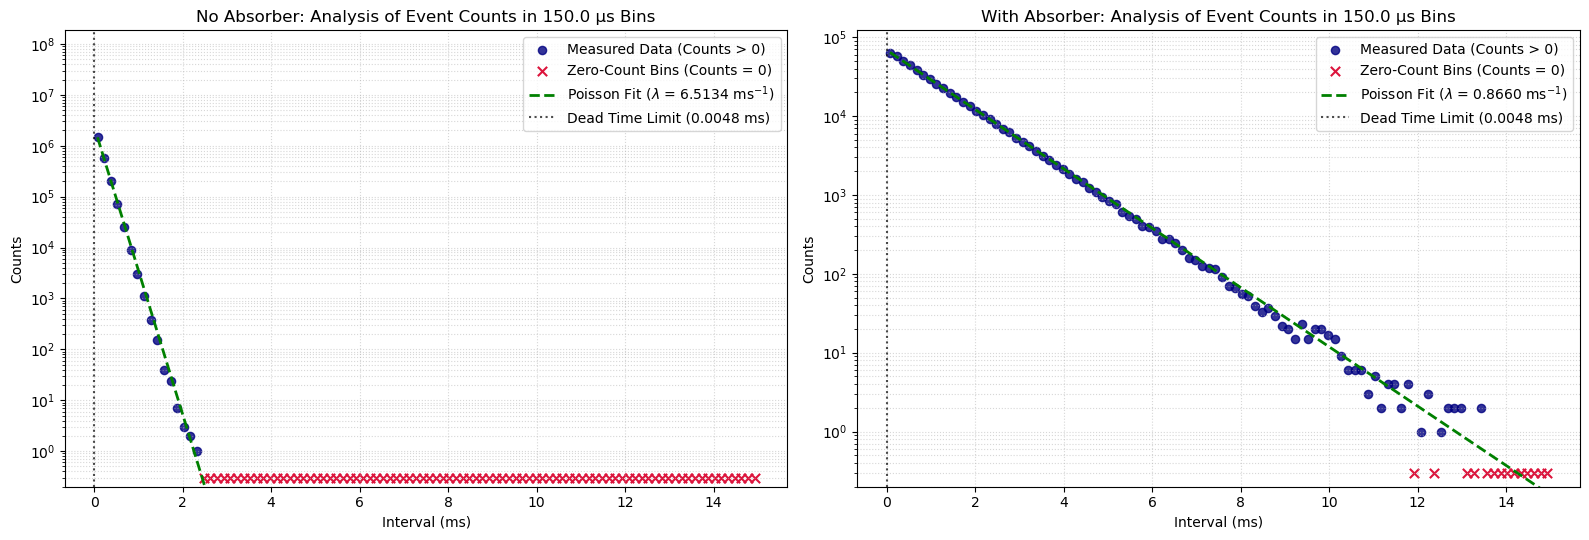

In [ ]:

# --- 2. Configurations & Data Loading ---
RUN_CONFIGS = [
    {"runfile": runfiles[0], "label": "No Absorber"},
    {"runfile": runfiles[1], "label": "With Absorber"},
]


# Sequential loading and mapping
processed_runs = []
for config in RUN_CONFIGS:
    data = load_and_process_run(config["runfile"])
    data["label"] = config["label"]
    processed_runs.append(data)


# --- 3. Dynamic Plotting Pipeline ---
fig, axes = plt.subplots(
    1, len(processed_runs), figsize=(8 * len(processed_runs), 5.5)
)
if len(processed_runs) == 1:
    axes = [axes]

for run, ax in zip(processed_runs, axes):
    ts_us = run["ts_us"]
    label_prefix = run["label"]

    # Compute inter-arrival times (dt) in milliseconds
    dt_ms = np.diff(ts_us.astype(np.float64)) / 1e3

    # Histogram calculation
    bins = 100
    # counts, bin_edges = np.histogram(dt_ms, bins=bins)
    # Limit the histogram range to sub-20 ms range
    counts, bin_edges = np.histogram(dt_ms, bins=100, range=(0, 15))

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]  # Bin width in ms

    # Fit region above dead time cutoff (4.8 us = 0.0048 ms)
    dead_time_ms = 4.8 / 1e3
    mask = bin_centers > dead_time_ms

    fit_x = bin_centers[mask]
    fit_y = counts[mask]
    N_valid = np.sum(fit_y)

    # Normalized 1-parameter exponential model
    def exp_func(
        dt,
        lmbda,
        N_valid=N_valid,
        bin_width=bin_width,
        dead_time_ms=dead_time_ms,
    ):
        return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_ms))

    # Perform fit
    popt, _ = curve_fit(exp_func, fit_x, fit_y, p0=[1.0])
    fit_lambda = popt[0]

    # Plotting
    nonzero_mask = counts > 0
    zero_mask = counts == 0

    # Non-zero counts
    ax.scatter(
        bin_centers[nonzero_mask],
        counts[nonzero_mask],
        color="navy",
        alpha=0.8,
        s=35,
        label="Measured Data (Counts > 0)",
    )

    # Zero counts
    baseline_zero_y = 0.3
    ax.scatter(
        bin_centers[zero_mask],
        np.full(np.sum(zero_mask), baseline_zero_y),
        color="crimson",
        marker="x",
        s=45,
        linewidth=1.5,
        label="Zero-Count Bins (Counts = 0)",
    )

    # Exponential fit curve
    ax.plot(
        fit_x,
        exp_func(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\mathrm{{ms}}^{{-1}}$)",
    )

    # Dead time threshold vertical line
    ax.axvline(
        dead_time_ms,
        color="black",
        linestyle=":",
        alpha=0.7,
        label=f"Dead Time Limit ({dead_time_ms:.4f} ms)",
    )

    ax.set_yscale("log")
    ax.set_ylim(bottom=0.2)
    ax.set_xlabel(r"Interval (ms)")
    # ax.set_xlim(0,÷00)
    ax.set_ylabel("Counts")
    ax.set_title(
        f"{label_prefix}: Analysis of Event Counts in {bin_width * 1e3:.1f} µs Bins"
    )
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# energy_datasets = [
#     (energy_old, "Old Energy Spectrum", axes[0]),
#     (energy_new, "New Energy Spectrum", axes[1]),
# ]

# for energy, title, ax in energy_datasets:
#     adu = range(int(max(energy)) + 1)
#     ax.hist(energy, bins=adu, log=True)
#     ax.set_title(title)
#     ax.set_xlabel("Energy / ADC Channel")
#     ax.set_ylabel("Counts (log scale)")
#     ax.set_xlim(kev_to_adu(13.3),kev_to_adu(15.5))

# plt.tight_layout()
# plt.show()


In [ ]:
import numpy as np

# --- Energy Histogram Extraction from processed_runs ---
h_all = []
adu_all = []

for run in processed_runs:
    energy = run["energy"]
    label = run["label"]  # "No Absorber" or "With Absorber"

    # Define integer ADU bins spanning the min-to-max range
    min_adu = int(np.floor(np.min(energy)))
    max_adu = int(np.ceil(np.max(energy)))
    bins = np.arange(min_adu, max_adu + 2)

    # Compute histogram
    h, b = np.histogram(energy, bins=bins)
    bin_centers = 0.5 * (b[:-1] + b[1:])  # Proper bin centers instead of right edges

    h_all.append(h)
    adu_all.append(bin_centers)


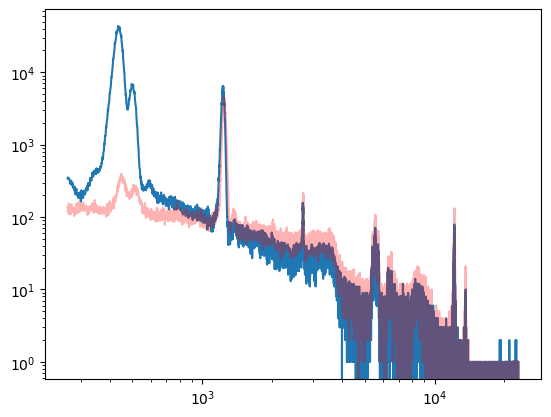

In [ ]:
plt.plot(adu_all[0],h_all[0], label ='Without Absorber')
plt.plot(adu_all[1],h_all[1], alpha =0.3, color = 'red', label = 'With Absorber')
plt.yscale('log')
plt.xscale('log')
# plt.xlim(kev_to_adu(13),kev_to_adu(16))

##RATE WITH AND WITHOUT ABSORBR

In [ ]:
h_all[1].sum()/(60*10),h_all[0].sum()/(60*10) 

(np.float64(873.7483333333333), np.float64(3946.9133333333334))

[No Absorber] Found 266614 events in the 13.3 - 15.5 keV range.
Grouped into 8575 70.0-ms intervals.
Max events in a single interval: 76
Variance/Mean Ratio: 19.241  (Ideal: ~1.0)
Chi-Squared (χ²): 2927.262
Reduced Chi-Squared (χ²/dof): 59.740
Fitted Lambda (λ): 51.239

5047


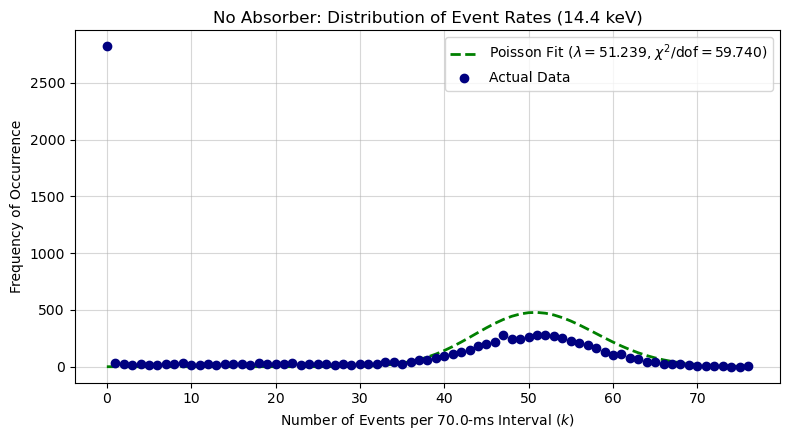

[With Absorber] Found 209980 events in the 13.3 - 15.5 keV range.
Grouped into 8557 70.0-ms intervals.
Max events in a single interval: 44
Variance/Mean Ratio: 0.984  (Ideal: ~1.0)
Chi-Squared (χ²): 40.825
Reduced Chi-Squared (χ²/dof): 1.134
Fitted Lambda (λ): 24.498

1016


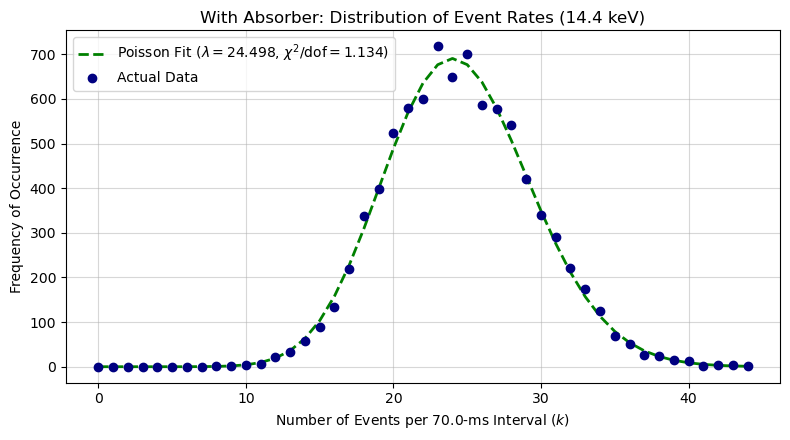

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import poisson


def graph_poissonian(
    run, e_start=13.3, e_end=15.5, bin_width_us=50000, save=False
):
    """Fits and plots a Poisson distribution of event counts per time interval

    for a given run dictionary from `processed_runs`.
    """
    file_label = run["label"]
    energy_data = run["energy"]
    ts_us_data = run["ts_us"]

    # Convert energy ADU to keV
    energy_kev = adu_to_kev(energy_data)

    # Filter for the e_start - e_end keV range
    mask = (energy_kev >= e_start) & (energy_kev <= e_end)
    filtered_times_us = ts_us_data[mask]
    n_events = len(filtered_times_us)

    if len(ts_us_data) == 0 or n_events == 0:
        print(
            f"[{file_label}] No events to process in {e_start}-{e_end} keV range."
        )
        return

    # Filtered range parameters
    start_time = ts_us_data[0]
    end_time = ts_us_data[-1]

    # Bin time into fixed intervals
    time_bins = np.arange(start_time, end_time + bin_width_us, bin_width_us)
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)

    bin_ms = bin_width_us / 1e3
    print(
        f"[{file_label}] Found {n_events} events in the {e_start} - {e_end} keV range."
    )
    print(f"Grouped into {len(frequencies)} {bin_ms:.1f}-ms intervals.")
    print(f"Max events in a single interval: {np.max(frequencies)}")

    max_count = int(np.max(frequencies))
    integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

    # Calculate count frequency histogram
    counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # Exact integers: 0, 1, 2...
    total_intervals = len(frequencies)
    sample_mean = np.mean(frequencies)


    # # 1. Filter out completely silent intervals (or set a threshold above idle noise)
    # active_frequencies = frequencies[frequencies > 0]  # Exclude dead/idle bins

    # # 2. Calculate histogram on active intervals only
    # max_count = int(np.max(active_frequencies))
    # integer_bins = np.arange(0.5, max_count + 1.5, 1.0)  # Start at k = 1

    # counts, bin_edges = np.histogram(active_frequencies, bins=integer_bins)
    # bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    # total_active_intervals = len(active_frequencies)


    # # 3. Normalized PMF for active intervals
    # def poisson_pmf(k, lmbda):
    #     return total_active_intervals * poisson.pmf(np.round(k).astype(int), lmbda)


    # # Perform fit on active region
    # popt, _ = curve_fit(poisson_pmf, bin_centers, counts, p0=[np.mean(active_frequencies)])



    # Robust Poisson PMF using scipy.stats.poisson (prevents factorial overflow)
    def poisson_pmf(k, lmbda):
        return total_intervals * poisson.pmf(np.round(k).astype(int), lmbda)

    # Perform curve fit using sample mean as initial guess
    sample_mean = np.mean(frequencies)
    popt, pcov = curve_fit(
        poisson_pmf,
        bin_centers,
        counts,
        p0=[sample_mean if sample_mean > 0 else 1.0],
    )
    
    fit_lambda = popt[0]

    # Goodness-of-Fit Metrics
    observed = counts
    expected = poisson_pmf(bin_centers, fit_lambda)

    valid_bins = expected > 0.5
    obs = observed[valid_bins]
    exp = expected[valid_bins]
    sigma = np.sqrt(exp)

    chi_squared = np.sum(((obs - exp) / sigma) ** 2)
    dof = len(obs) - len(popt)
    reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan

    sample_var = np.var(frequencies)
    dispersion = sample_var / sample_mean if sample_mean > 0 else 0

    print(f"Variance/Mean Ratio: {dispersion:.3f}  (Ideal: ~1.0)")
    print(f"Chi-Squared (χ²): {chi_squared:.3f}")
    print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")
    print(f"Fitted Lambda (λ): {fit_lambda:.3f}\n")

    # Plotting
    plt.figure(figsize=(8, 4.5))

    fit_k = np.arange(0, max_count + 1)
    plt.plot(
        fit_k,
        poisson_pmf(fit_k, fit_lambda),
        "g--",
        linewidth=2,
        label=f"Poisson Fit ($\lambda = {fit_lambda:.3f}$, $\chi^2/\mathrm{{dof}} = {reduced_chi_squared:.3f}$)",
    )

    plt.plot(
        bin_centers,
        counts,
        marker="o",
        linestyle="",
        color="navy",
        label="Actual Data",
    )

    average_kev = 0.5 * (e_start + e_end)
    plt.title(
        f"{file_label}: Distribution of Event Rates ({average_kev:.1f} keV)"
    )
    plt.xlabel(f"Number of Events per {bin_ms:.1f}-ms Interval ($k$)")
    plt.ylabel("Frequency of Occurrence")

    plt.legend()
    plt.grid(True, alpha=0.5)
    # plt.ylim(0, 300)
    plt.tight_layout()

    if save:
        clean_label = file_label.lower().replace(" ", "_")
        base_path = Path(f"poisson_fit_{clean_label}_{average_kev:.1f}kev.png")
        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = base_path.with_name(
                f"{base_path.stem}_{counter}{base_path.suffix}"
            )
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    print_mask = (bin_centers > 30) & (bin_centers < 70)

    print(np.sum(counts[print_mask]))
    plt.show()


for run in processed_runs:
    graph_poissonian(run, e_start=13.3, e_end=15.5, bin_width_us=7e4, save=False)


[No Absorber] Found 266614 events in the 13.3 - 15.5 keV range.
Grouped into 8575 70.0-ms intervals.
Max events in a single interval: 76
Variance/Mean Ratio: 19.241  (Ideal: ~1.0)
Chi-Squared (χ²): 2926.221
Reduced Chi-Squared (χ²/dof): 59.719
Fitted Lambda (λ): 51.239



IndexError: boolean index did not match indexed array along axis 0; size of axis is 74 but size of corresponding boolean axis is 22734

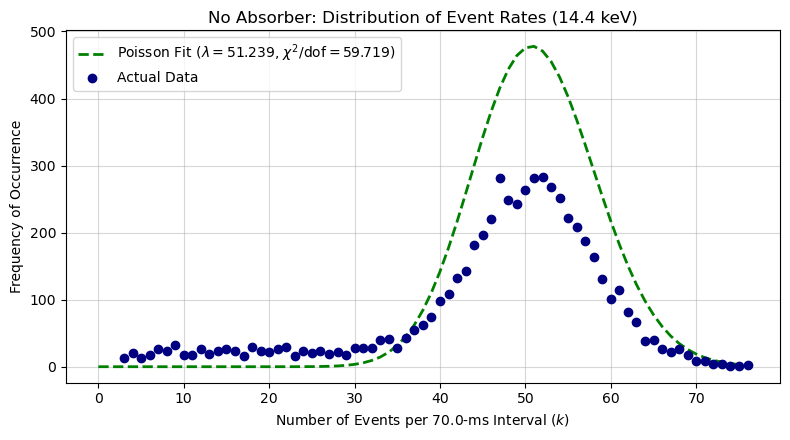

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import poisson


def graph_poissonian(
    run, e_start=13.3, e_end=15.5, bin_width_us=50000, save=False
):
    """Fits and plots a Poisson distribution of event counts per time interval

    for a given run dictionary from `processed_runs`.
    """
    file_label = run["label"]
    energy_data = run["energy"]
    ts_us_data = run["ts_us"]

    # Convert energy ADU to keV
    energy_kev = adu_to_kev(energy_data)

    # Filter for the e_start - e_end keV range
    mask = (energy_kev >= e_start) & (energy_kev <= e_end)
    filtered_times_us = ts_us_data[mask]
    n_events = len(filtered_times_us)

    if len(ts_us_data) == 0 or n_events == 0:
        print(
            f"[{file_label}] No events to process in {e_start}-{e_end} keV range."
        )
        return

    # Filtered range parameters
    start_time = ts_us_data[0]
    end_time = ts_us_data[-1]

    # Bin time into fixed intervals
    time_bins = np.arange(start_time, end_time + bin_width_us, bin_width_us)

    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    # time_bins = time_bins[3:]
    # frequencies = frequencies[3:]
    bin_ms = bin_width_us / 1e3
    print(
        f"[{file_label}] Found {n_events} events in the {e_start} - {e_end} keV range."
    )
    print(f"Grouped into {len(frequencies)} {bin_ms:.1f}-ms intervals.")
    print(f"Max events in a single interval: {np.max(frequencies)}")

    max_count = int(np.max(frequencies))
    integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

    # Calculate count frequency histogram
    counts, bin_edges = np.histogram(frequencies, bins=integer_bins)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # Exact integers: 0, 1, 2...
    counts = counts[3:]
    bin_centers = bin_centers[3:]

    total_intervals = len(frequencies)-3
    sample_mean = np.mean(frequencies)




    # Robust Poisson PMF using scipy.stats.poisson (prevents factorial overflow)
    def poisson_pmf(k, lmbda):
        return total_intervals * poisson.pmf(np.round(k).astype(int), lmbda)
    
    # Perform curve fit using sample mean as initial guess
    sample_mean = np.mean(frequencies)
    popt, pcov = curve_fit(
        poisson_pmf,
        bin_centers,
        counts,
        p0=[sample_mean if sample_mean > 0 else 1.0],
    )
    
    fit_lambda = popt[0]

    # Goodness-of-Fit Metrics
    observed = counts
    expected = poisson_pmf(bin_centers, fit_lambda)

    valid_bins = expected > 0.5
    obs = observed[valid_bins]
    exp = expected[valid_bins]
    sigma = np.sqrt(exp)

    chi_squared = np.sum(((obs - exp) / sigma) ** 2)
    dof = len(obs) - len(popt)
    reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan

    sample_var = np.var(frequencies)
    dispersion = sample_var / sample_mean if sample_mean > 0 else 0

    print(f"Variance/Mean Ratio: {dispersion:.3f}  (Ideal: ~1.0)")
    print(f"Chi-Squared (χ²): {chi_squared:.3f}")
    print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")
    print(f"Fitted Lambda (λ): {fit_lambda:.3f}\n")

    # Plotting
    plt.figure(figsize=(8, 4.5))

    fit_k = np.arange(0, max_count + 1)
    plt.plot(
        fit_k,
        poisson_pmf(fit_k, fit_lambda),
        "g--",
        linewidth=2,
        label=f"Poisson Fit ($\lambda = {fit_lambda:.3f}$, $\chi^2/\mathrm{{dof}} = {reduced_chi_squared:.3f}$)",
    )

    plt.plot(
        bin_centers,
        counts,
        marker="o",
        linestyle="",
        color="navy",
        label="Actual Data",
    )

    average_kev = 0.5 * (e_start + e_end)
    plt.title(
        f"{file_label}: Distribution of Event Rates ({average_kev:.1f} keV)"
    )
    plt.xlabel(f"Number of Events per {bin_ms:.1f}-ms Interval ($k$)")
    plt.ylabel("Frequency of Occurrence")

    plt.legend()
    plt.grid(True, alpha=0.5)
    # plt.ylim(0, 300)
    plt.tight_layout()

    if save:
        clean_label = file_label.lower().replace(" ", "_")
        base_path = Path(f"poisson_fit_{clean_label}_{average_kev:.1f}kev.png")
        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = base_path.with_name(
                f"{base_path.stem}_{counter}{base_path.suffix}"
            )
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    print_mask = (bins> 30) & (bins < 70)
    print(np.sum(counts[print_mask]))
    plt.show()


for run in processed_runs:
    graph_poissonian(run, e_start=13.3, e_end=15.5, bin_width_us=7e4, save=False)


In [ ]:

times = np.asarray(ts_us, dtype=np.float64)   # seconds
adu = np.asarray(energy, dtype=np.int32)

dt = np.diff(times)
dadu = np.diff(adu)
abs_dadu = np.abs(dadu)

# Select time-spacing groups
nonzero_mask = dt > 0
zero_mask = np.isclose(dt, 0.0, atol=1e-9)



def summarize(label, mask):
    values = abs_dadu[mask]

    if values.size == 0:
        print(f"{label}: no matching pairs")
        return

    mean_abs = np.mean(values)
    max_abs = np.max(values)

    print(f"{label}")
    print(f"  Number of pairs:       {values.size}")
    print(f"  Mean absolute ΔkeV:    {adu_to_kev(mean_abs):.3f}")
    print(f"  Max absolute ΔkeV:  {adu_to_kev(max_abs):.3f}")









summarize("Δt = 0", zero_mask)
summarize("Δt > 0", nonzero_mask)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 524394 but size of corresponding boolean axis is 524248